In [92]:
import polars as pl
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import structlog
import config

In [93]:
# 1. Aggregate Features per Store from Gold Data
# We lazily scan the Gold dataset and collapse 470,000 rows into exactly 45 rows (one per store)
lf = pl.scan_parquet(config.GOLD_DATA_PATH)

store_profiles = lf.group_by("store").agg([
    pl.col("weekly_sales").mean().alias("avg_weekly_sales"),
    pl.col("store_size").first().alias("store_size"),
    # We fill nulls with 0 for markdowns before averaging to get true responsiveness
    pl.col("total_markdown").fill_null(0).mean().alias("avg_weekly_markdown")
]).collect().to_pandas()
print(store_profiles.head(), '\n', store_profiles.shape)


   store  avg_weekly_sales  store_size  avg_weekly_markdown
0      3       5593.232893       37392          2434.802002
1      9       7451.974837      125833          3428.353760
2      6      20321.368481      202505          8226.326172
3     12      13453.719959      112238          9512.517578
4     15       7890.136165      123737          4849.903809 
 (45, 4)


In [94]:
# 2. Standardize Features
# K-Means calculates physical distance between points. If we don't scale, 
# 'store_size' (200,000) will overpower 'avg_weekly_sales' ($15,000) simply because the raw number is larger.
scaler = StandardScaler()
features_to_scale = store_profiles.drop("store", axis=1)
print(features_to_scale.head())
X_scaled = scaler.fit_transform(features_to_scale)
print(X_scaled[:5])

   avg_weekly_sales  store_size  avg_weekly_markdown
0       5593.232893       37392          2434.802002
1       7451.974837      125833          3428.353760
2      20321.368481      202505          8226.326172
3      13453.719959      112238          9512.517578
4       7890.136165      123737          4849.903809
[[-1.23662262 -1.47191384 -1.11773032]
 [-0.95812559 -0.07058232 -0.8280069 ]
 [ 0.97010759  1.14427153  0.57109984]
 [-0.05887856 -0.28599262  0.94615808]
 [-0.89247548 -0.10379306 -0.41347758]]


In [95]:
# 3. Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
store_profiles['Cluster'] = kmeans.fit_predict(X_scaled)

In [96]:
store_profiles.head()

,store,avg_weekly_sales,store_size,avg_weekly_markdown,Cluster
0,3,5593.232893,37392,2434.802002,1
1,9,7451.974837,125833,3428.353760,2
2,6,20321.368481,202505,8226.326172,0
3,12,13453.719959,112238,9512.517578,2
4,15,7890.136165,123737,4849.903809,2


In [97]:
# 4. Evaluate Segmentation Quality
# Silhouette Score ranges from -1 (terrible) to +1 (perfectly separated dense clusters)
score = silhouette_score(X_scaled, store_profiles['Cluster'])
print(score)

0.5219686169797556


In [98]:
# Let's log the center of each cluster so we can understand the "Archetypes"
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features_to_scale.columns)
cluster_centers.index.name = 'Cluster'
print(cluster_centers.round(0))



         avg_weekly_sales  store_size  avg_weekly_markdown
Cluster                                                   
0                 21055.0    195622.0               9406.0
1                  6692.0     47436.0               1794.0
2                 11877.0    128047.0               6589.0


In [99]:
store_profiles['Cluster'].unique()

array([1, 2, 0], dtype=int32)

In [100]:
# 5. Map mathematical clusters to Corporate Retail Taxonomy
# Based on the K=3 cluster centers:
taxonomy_mapping = {
    2: "Supercenter (Flagship)",
    0: "Standard Discount Store",
    1: "Neighborhood Market (Express)"
}
store_profiles['Archetype'] = store_profiles['Cluster'].map(taxonomy_mapping)


In [101]:
store_profiles.head()

,store,avg_weekly_sales,store_size,avg_weekly_markdown,Cluster,Archetype
0,3,5593.232893,37392,2434.802002,1,Neighborhood Market (Express)
1,9,7451.974837,125833,3428.353760,2,Supercenter (Flagship)
2,6,20321.368481,202505,8226.326172,0,Standard Discount Store
3,12,13453.719959,112238,9512.517578,2,Supercenter (Flagship)
4,15,7890.136165,123737,4849.903809,2,Supercenter (Flagship)


#### Elbow method to find optimal k
    - the algorithm calculates Inertia (also known as the "Within-Cluster Sum of Squares").
    - how tightly packed the data points are within their clusters

In [102]:
# We will test K from 1 to 10 clusters
inertias = []
k_range = range(1, 11)
for k in k_range:
    # Train a temporary model for each K
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_test.fit(X_scaled)
    # Record the mathematical tightness (inertia)
    inertias.append(kmeans_test.inertia_)

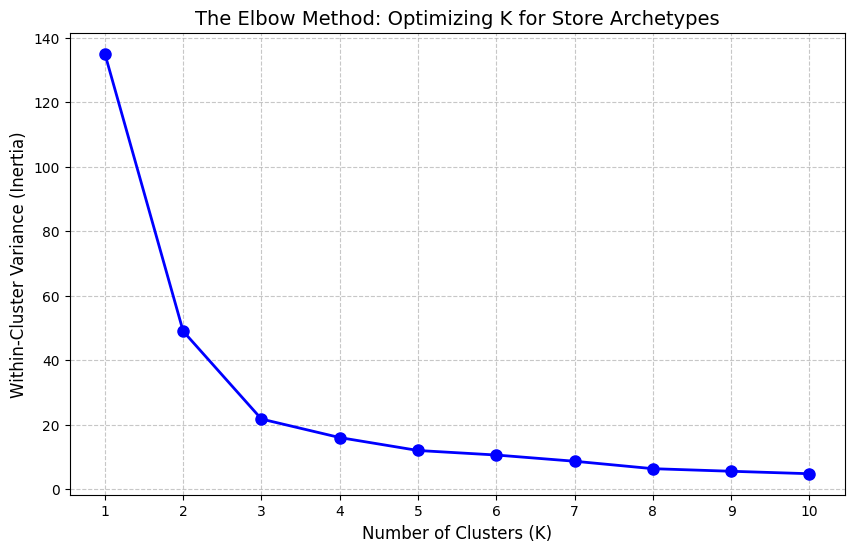

In [103]:
# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title('The Elbow Method: Optimizing K for Store Archetypes', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Variance (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Visualizing the clustors

In [104]:
import plotly.express as px

# 1. Cast the Cluster column to a string so Plotly treats it as distinct colors, not a gradient
store_profiles['Cluster'] = store_profiles['Cluster'].astype(str)

# 2. Generate the 3D Scatter Plot
fig = px.scatter_3d(
    store_profiles,
    x='avg_weekly_sales',
    y='store_size',
    z='avg_weekly_markdown',
    color='Cluster',
    title='Store Archetypes: 3D K-Means Cluster Space',
    labels={
        'avg_weekly_sales': 'Avg Weekly Sales ($)',
        'store_size': 'Store Size (Sq Ft)',
        'avg_weekly_markdown': 'Avg Weekly Markdown ($)'
    },
    hover_data=['store'], # Hovering over a dot will reveal the exact Store ID!
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()
